Descripción del Notebook:

En este notebook estudiaremos e implementaremos la técnica de Fine-Tuning (Ajuste Fino). Descongelaremos las capas superiores del modelo base para adaptar sus representaciones a los rasgos específicos de nuestro nuevo conjunto de datos, aplicando un Learning Rate reducido para evitar el Catastrophic Forgetting.

🐍 Importación de Librerías y Configuración

In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

os.makedirs('../image', exist_ok=True)

🐍 Parte 1: Descongelado Progresivo del Modelo Base

In [2]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)

# Descongelar el modelo base completo
base_model.trainable = True

# Congelar hasta la capa 100 (descongelar solo capas superiores)
fine_tuning_at = 100
for layer in base_model.layers[:fine_tuning_at]:
  layer.trainable = False

print(
    f'Capas totales: {len(base_model.layers)} | Capas congeladas:'
    f' {fine_tuning_at}'
)

Capas totales: 154 | Capas congeladas: 100


🐍 Parte 2: Recompilación Obligatoria con Learning Rate Bajo

In [3]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# RECOMPILACIÓN OBLIGATORIA: Usando un Learning Rate muy bajo (1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print('¡Modelo recompilado correctamente con Learning Rate = 1e-5!')

¡Modelo recompilado correctamente con Learning Rate = 1e-5!


🐍 Parte 3: Generación del Diagrama de Fine-Tuning

C:\Users\acer\AppData\Local\Temp\ipykernel_6276\1087394207.py:66: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\acer\AppData\Local\Temp\ipykernel_6276\1087394207.py:66: UserWarning: Glyph 128275 (\N{OPEN LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\acer\AppData\Local\Temp\ipykernel_6276\1087394207.py:66: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\acer\AppData\Local\Temp\ipykernel_6276\1087394207.py:67: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.savefig(
C:\Users\acer\AppData\Local\Temp\ipykernel_6276\1087394207.py:67: UserWarning: Glyph 128275 (\N{OPEN LOCK}) missing from font(s) DejaVu Sans.
  plt.savefig(
C:\Users\acer\AppData\Local\Temp\ipykernel_6276\1087394207.py:67: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig(
c:\Users\acer\Transfer-Learning-Masterclass\.venv\Lib\site-p

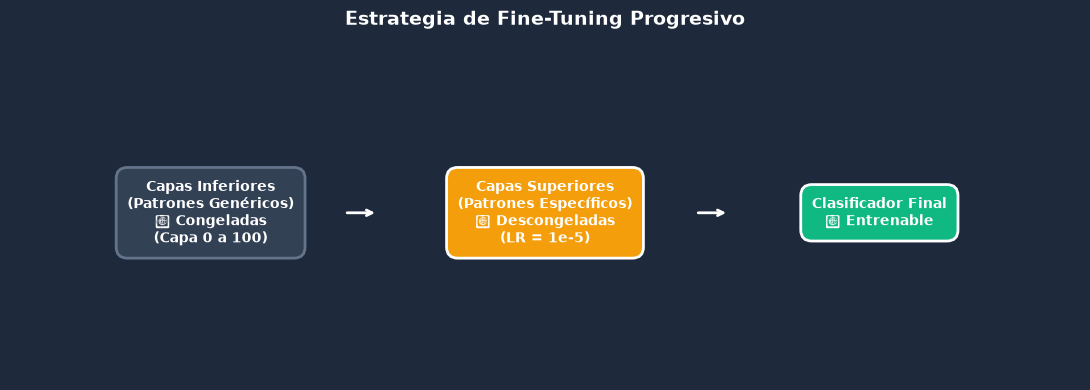

Imagen guardada en: ../image/fine_tuning_schema.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 4), facecolor='#1e293b')
ax.set_facecolor('#1e293b')

ax.text(
    1.2,
    0.5,
    'Capas Inferiores\n(Patrones Genéricos)\n🔒 Congeladas\n(Capa 0 a 100)',
    ha='center',
    va='center',
    color='white',
    weight='bold',
    bbox=dict(
        boxstyle='round,pad=0.8', facecolor='#334155', edgecolor='#64748b', lw=2
    ),
)

ax.text(
    3.2,
    0.5,
    'Capas Superiores\n(Patrones Específicos)\n🔓 Descongeladas\n(LR = 1e-5)',
    ha='center',
    va='center',
    color='white',
    weight='bold',
    bbox=dict(
        boxstyle='round,pad=0.8', facecolor='#f59e0b', edgecolor='white', lw=2
    ),
)

ax.text(
    5.2,
    0.5,
    'Clasificador Final\n🔥 Entrenable',
    ha='center',
    va='center',
    color='white',
    weight='bold',
    bbox=dict(
        boxstyle='round,pad=0.8', facecolor='#10b981', edgecolor='white', lw=2
    ),
)

ax.annotate(
    '',
    xy=(2.2, 0.5),
    xytext=(2.0, 0.5),
    arrowprops=dict(arrowstyle='->', color='white', lw=2),
)
ax.annotate(
    '',
    xy=(4.3, 0.5),
    xytext=(4.1, 0.5),
    arrowprops=dict(arrowstyle='->', color='white', lw=2),
)

ax.set_xlim(0, 6.4)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title(
    'Estrategia de Fine-Tuning Progresivo',
    color='white',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.tight_layout()
plt.savefig(
    '../image/fine_tuning_schema.png', dpi=300, facecolor=fig.get_facecolor()
)
plt.show()
print("Imagen guardada en: ../image/fine_tuning_schema.png")

Resumen de lo aprendido:

*   Descongelado estratégicamente solo de las capas superiores (a partir de la 100).

*   Se comprendió que tras modificar trainable es estrictamente necesario recompilar el modelo (model.compile()).

*   Fijado un Learning Rate de 1e-5 para evitar distorsionar los pesos preentrenados y generamos el archivo fine_tuning_schema.png.